In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from scipy.stats import pointbiserialr
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option('display.max_columns', None)


## Vinculacion con Carpeta de Datos
### Se hace una revision inicial del dataset, mostrando las columnas y las primeras 5 filas

In [2]:
# Cargar el dataset, cambiar ruta dependiendo de tu ubicación
ruta = r"C:\Users\mejia\Desktop\Estudio\IA\Proyecto4-IA\Datos\data.csv"
df = pd.read_csv(ruta)

# Mostrar las primeras filas
df.head(5)


,Age,Height_cm,Weight_kg,Position,Training_Hours_Per_Week,Matches_Played_Past_Season,Previous_Injury_Count,Knee_Strength_Score,Hamstring_Flexibility,Reaction_Time_ms,Balance_Test_Score,Sprint_Speed_10m_s,Agility_Score,Sleep_Hours_Per_Night,Stress_Level_Score,Nutrition_Quality_Score,Warmup_Routine_Adherence,Injury_Next_Season,BMI
0,22,173,64,Midfielder,11.575308,36,1,77.460279,79.115738,284.487853,91.212476,5.874630,77.599705,8.238293,46.616415,81.472206,1,0,21.383942
1,18,170,67,Midfielder,12.275869,37,2,72.634442,82.541688,250.579249,87.294078,5.796269,94.418987,8.983737,49.368037,81.056677,1,0,23.183391
2,22,186,75,Forward,12.254896,12,2,77.064490,75.943631,269.119918,83.440688,5.731209,70.179176,7.229193,43.132808,64.877457,0,1,21.678807
3,20,172,62,Defender,9.006678,11,1,82.810232,73.878324,226.376412,87.591894,6.220212,83.473824,7.681029,51.528529,89.824744,1,0,20.957274
4,18,172,94,Midfielder,12.683668,10,2,76.772859,76.653043,229.021042,83.125161,5.385958,87.037256,6.728091,52.379718,71.569197,0,1,31.773932


### Resumen de estadisticos, cantidad de valores no nulos y los tipos de datos

In [3]:
# Ver tamaño y columnas
print("Filas y columnas:", df.shape)
print("\nColumnas:\n", df.columns.tolist())

df.info()
df.describe()


Filas y columnas: (800, 19)

Columnas:
 ['Age', 'Height_cm', 'Weight_kg', 'Position', 'Training_Hours_Per_Week', 'Matches_Played_Past_Season', 'Previous_Injury_Count', 'Knee_Strength_Score', 'Hamstring_Flexibility', 'Reaction_Time_ms', 'Balance_Test_Score', 'Sprint_Speed_10m_s', 'Agility_Score', 'Sleep_Hours_Per_Night', 'Stress_Level_Score', 'Nutrition_Quality_Score', 'Warmup_Routine_Adherence', 'Injury_Next_Season', 'BMI']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         800 non-null    int64  
 1   Height_cm                   800 non-null    int64  
 2   Weight_kg                   800 non-null    int64  
 3   Position                    800 non-null    object 
 4   Training_Hours_Per_Week     800 non-null    float64
 5   Matches_Played_Past_Season  800 non-null    int64  
 6   Previo

,Age,Height_cm,Weight_kg,Training_Hours_Per_Week,Matches_Played_Past_Season,Previous_Injury_Count,Knee_Strength_Score,Hamstring_Flexibility,Reaction_Time_ms,Balance_Test_Score,Sprint_Speed_10m_s,Agility_Score,Sleep_Hours_Per_Night,Stress_Level_Score,Nutrition_Quality_Score,Warmup_Routine_Adherence,Injury_Next_Season,BMI
count,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,21.135000,177.407500,73.235000,9.951150,22.332500,1.536250,74.933249,79.154123,249.423244,83.832337,5.949025,78.341311,7.417124,54.039342,74.382174,0.597500,0.500000,23.377364
std,1.991037,7.148974,9.929276,2.610395,10.311516,1.292584,6.672704,6.782332,22.532387,6.931657,0.329133,8.775418,0.793183,11.421143,9.324899,0.490708,0.500313,3.673279
min,18.000000,154.000000,45.000000,5.000000,5.000000,0.000000,52.391351,58.180381,180.000000,60.059484,4.862435,50.000000,5.000000,21.561186,50.000000,0.000000,0.000000,14.346326
25%,19.000000,173.000000,66.000000,8.127151,13.000000,1.000000,70.432656,74.495959,234.089585,79.044910,5.732552,72.675392,6.850062,45.775371,67.809084,0.000000,0.000000,20.786644
50%,21.000000,177.000000,73.000000,9.895710,22.000000,1.000000,74.997933,79.187909,249.127328,84.156236,5.937692,78.340973,7.424618,54.047208,74.363878,1.000000,0.500000,23.130560
75%,23.000000,182.000000,80.000000,11.535140,32.000000,2.000000,79.632391,83.813179,265.105082,88.877902,6.159205,84.093489,7.988100,61.910804,80.502613,1.000000,1.000000,26.024182
max,24.000000,200.000000,105.000000,18.866608,39.000000,8.000000,93.900051,100.000000,306.730851,100.000000,6.898228,100.000000,9.860553,87.065007,100.000000,1.000000,1.000000,36.262439


### Despues de hacer una revisión inicial del dataset, se inicia el proceso EDA (Exploratory Data Analysis)
## 1. Verificar % valores nulos

In [4]:
def null_percentage(df):
    """
    Calcula el porcentaje de valores nulos (NaN) por columna en un DataFrame.

    Parámetros:
        df (pd.DataFrame): DataFrame de pandas a analizar.

    Retorna:
        pd.DataFrame: Un DataFrame con dos columnas:
            - 'Column': nombre de la columna
            - 'Null_Percentage': porcentaje de valores nulos (0 a 100)
    """
    null_percent = df.isnull().mean() * 100  # porcentaje de NaN por columna
    result = null_percent.reset_index()      # reinicia el índice
    result.columns = ['Column', 'Null_Percentage']  # renombra columnas
    result = result.sort_values(by='Null_Percentage', ascending=False)  # ordena de mayor a menor
    
    return result
null_percentage(df)


,Column,Null_Percentage
0,Age,0.0
10,Balance_Test_Score,0.0
17,Injury_Next_Season,0.0
16,Warmup_Routine_Adherence,0.0
15,Nutrition_Quality_Score,0.0
14,Stress_Level_Score,0.0
13,Sleep_Hours_Per_Night,0.0
12,Agility_Score,0.0
11,Sprint_Speed_10m_s,0.0
9,Reaction_Time_ms,0.0


#### No se encuentran valores nulos, continuamos con el siguiente paso. 
## 2. Encontrar porcentaje de “0’s” y ver si tiene sentido tenerlos en variables numéricas.

In [5]:
def zero_percentage(df):
    """
    Calcula el porcentaje de valores iguales a cero por columna en un DataFrame.

    Parámetros:
        df (pd.DataFrame): DataFrame de pandas a analizar.

    Retorna:
        pd.DataFrame: Un DataFrame con dos columnas:
            - 'Column': nombre de la columna
            - 'Zero_Percentage': porcentaje de ceros (0 a 100)
    """
    zero_percent = (df == 0).mean() * 100  # calcula proporción de ceros
    result = zero_percent.reset_index()
    result.columns = ['Column', 'Zero_Percentage']
    result = result.sort_values(by='Zero_Percentage', ascending=False)
    
    return result

# 🔹 Ejemplo de uso:
zero_percentage(df)


,Column,Zero_Percentage
17,Injury_Next_Season,50.000
16,Warmup_Routine_Adherence,40.250
6,Previous_Injury_Count,23.125
0,Age,0.000
10,Balance_Test_Score,0.000
15,Nutrition_Quality_Score,0.000
14,Stress_Level_Score,0.000
13,Sleep_Hours_Per_Night,0.000
12,Agility_Score,0.000
11,Sprint_Speed_10m_s,0.000


### Las variables Injury_Next_Season, Warmup_Routin_Adherance y Previous_Injury_Count contienen ceros, sin embargo son correctos ya que las variables mencionadas son de tipo catergorica binaria donde los posibles valores son 0 = no o 1 = si.

## 3. Generar los gráficos correspondientes (histogramas, barras, correlación, etc) de cada variable

### a. Variables categoricas, graficos de barras

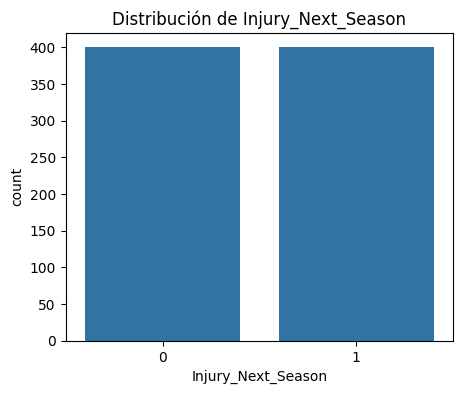

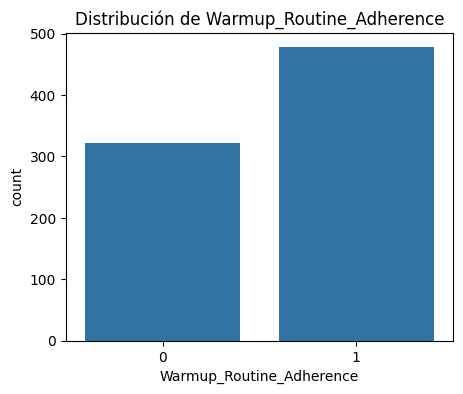

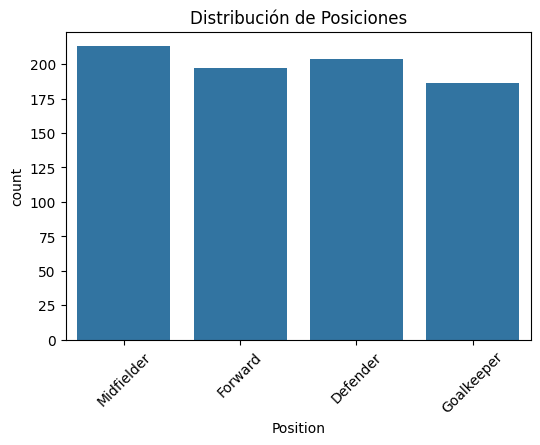

In [9]:
# --- Variables categóricas binarias ---
binarias = ['Injury_Next_Season', 'Warmup_Routine_Adherence']
for col in binarias:
    plt.figure(figsize=(5,4))
    sns.countplot(data=df, x=col)
    plt.title(f"Distribución de {col}")
    plt.show()

# --- Variable categórica multiclase ---
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Position')
plt.title("Distribución de Posiciones")
plt.xticks(rotation=45)
plt.show()

### Justificación
#### Para las variables categoricas binarias se emplearon gráficos de barras, los cuales muestran la frecuencia de cada categoría en una variable. Se emplearon para las variables: Injury_Next_Season, Warmup_Routine_Adherence, Position

### b. Variables cuantitativas, histogramas

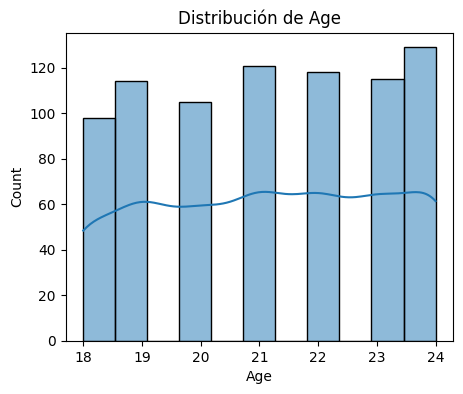

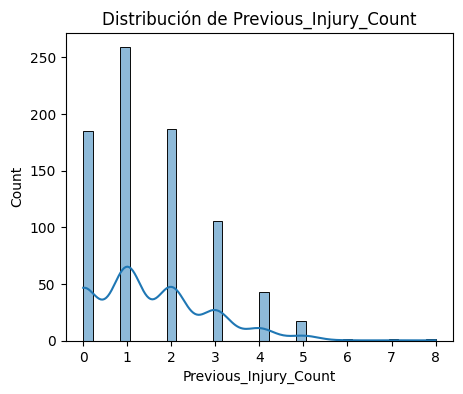

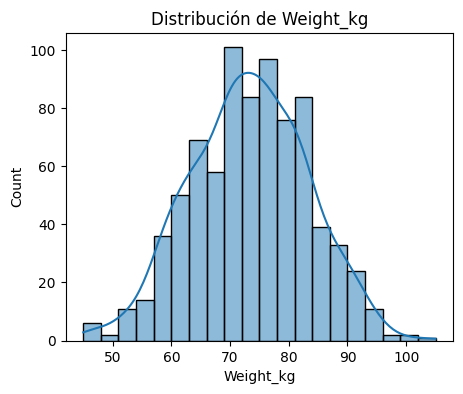

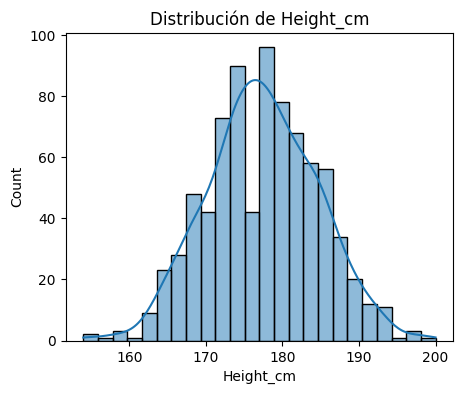

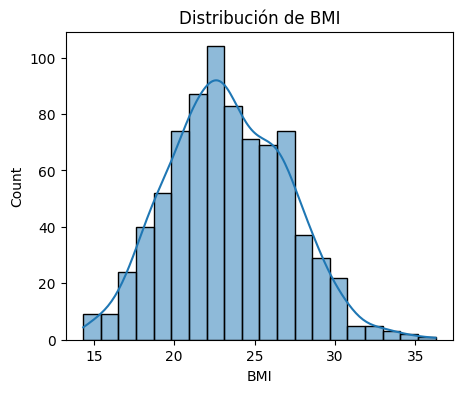

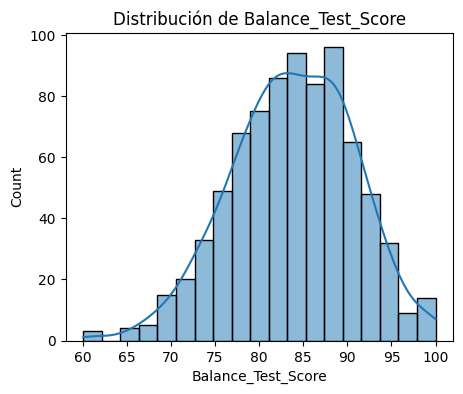

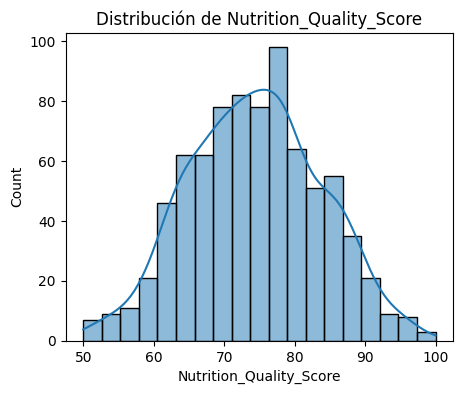

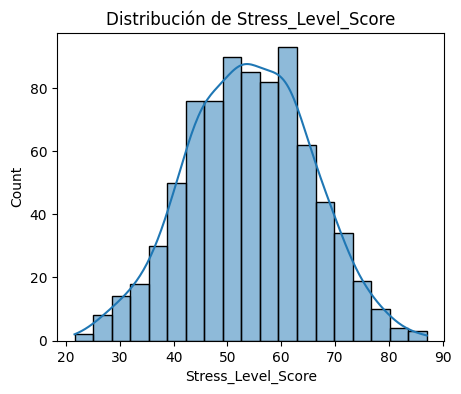

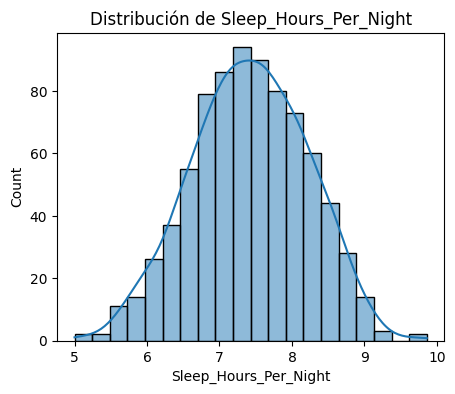

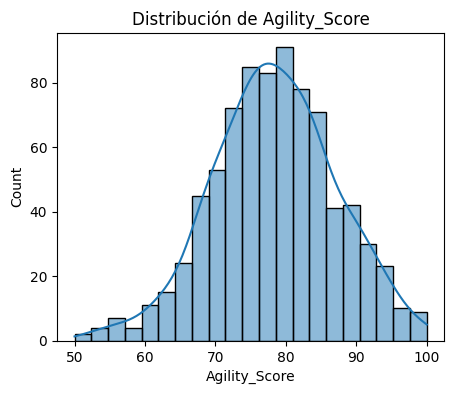

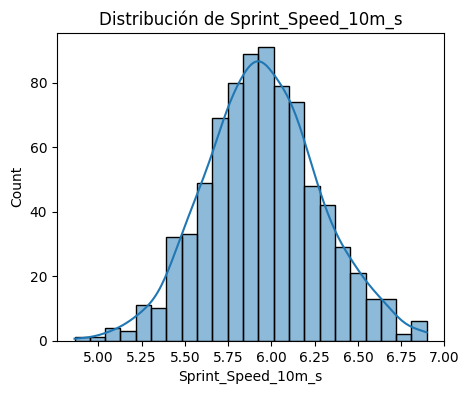

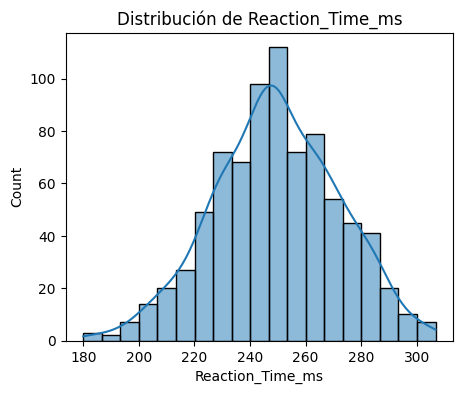

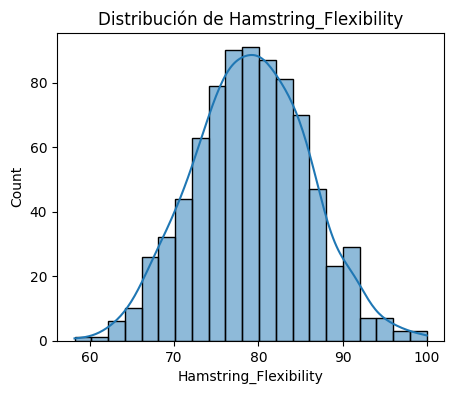

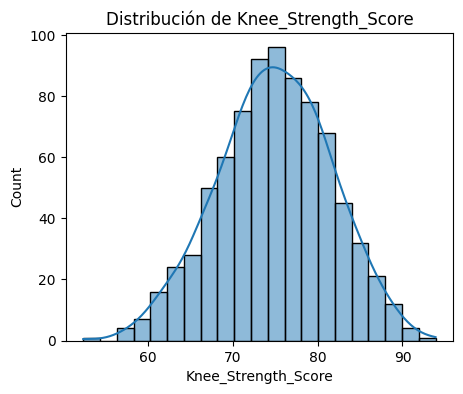

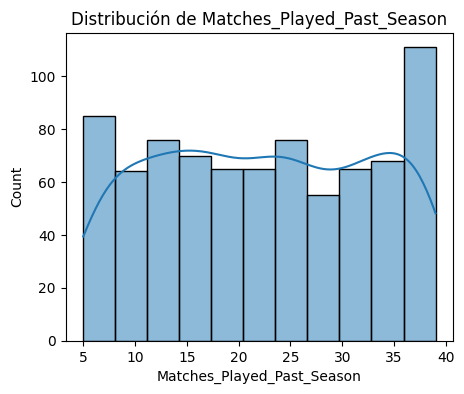

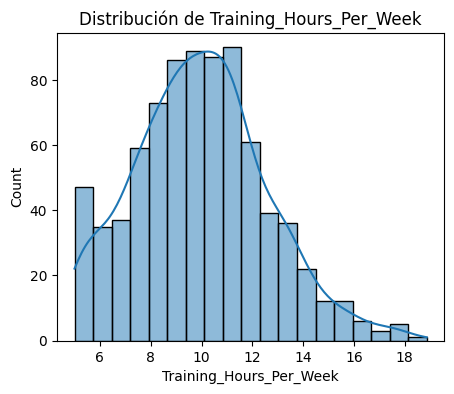

In [11]:
# --- Variables numéricas ---
numericas = [
    'Age', 'Previous_Injury_Count','Weight_kg','Height_cm','BMI','Balance_Test_Score','Nutrition_Quality_Score',
    'Stress_Level_Score','Sleep_Hours_Per_Night','Agility_Score','Sprint_Speed_10m_s',
    'Reaction_Time_ms','Hamstring_Flexibility','Knee_Strength_Score',
    'Matches_Played_Past_Season','Training_Hours_Per_Week'
]

for col in numericas:
    plt.figure(figsize=(5,4))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f"Distribución de {col}")
    plt.show()

### Justificación
#### Para las variables númericas continuas se utilizarón histogramas para evidenciar no solo la frecuencia sino tambien la forma de la distribución, con el fin de poder ver el comportamiento de los datos antes de entrenar el modelo.

## 4. Generar visualización de la variable de salida (que se quiere predecir)
### Objetivo 1

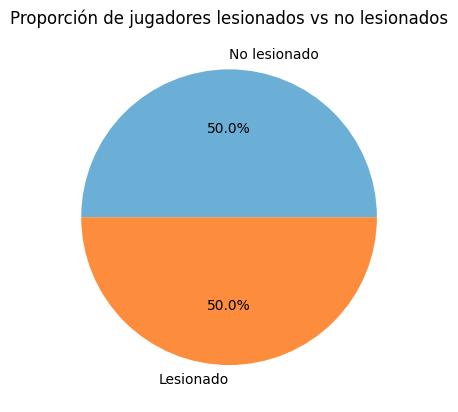

In [12]:
df['Injury_Next_Season'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['No lesionado', 'Lesionado'],
    colors=['#6baed6','#fd8d3c'],
    title='Proporción de jugadores lesionados vs no lesionados'
)
plt.ylabel('')
plt.show()

### Objetivo 2

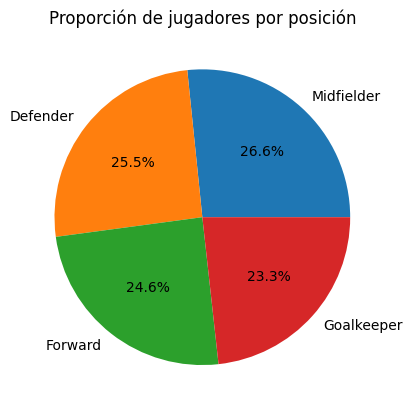

In [14]:
df['Position'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    title='Proporción de jugadores por posición'
)
plt.ylabel('')
plt.show()

### Justificacion
#### Los gráficos circulares permiten visualizar la proporción de cada categoría dentro de la variable objetivo. Esto resulta útil en problemas de clasificación, ya que facilita identificar posibles desequilibrios entre clases. En este caso, las categorías se encuentran equilibradas.

## 5. Eliminar registros con nulos, ceros o inconsistencias. Indicar y justificar la razón por la cual lo hicieron

### Justificacion
#### Durante este proceso de analisis de datos, no se hallaron valores nulos. Ademas, los ceros encontrados son validos. En cuanto a inconsistencias, a pesar de que los graficos anteriores indicaron la presencia de valores atipicos, no se consideran inconsistencias.

## 6. Eliminar las características que según el análisis no aplique (deben justificar la razón de por qué se eliminaron)

## Seleccion variables objetivo 1.

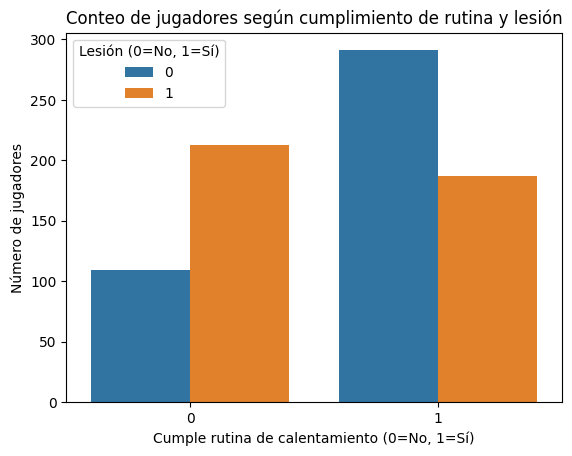

In [22]:
sns.countplot(data=df, x='Warmup_Routine_Adherence', hue='Injury_Next_Season')
plt.title("Conteo de jugadores según cumplimiento de rutina y lesión")
plt.xlabel("Cumple rutina de calentamiento (0=No, 1=Sí)")
plt.ylabel("Número de jugadores")
plt.legend(title="Lesión (0=No, 1=Sí)")
plt.show()


### Justificacion
#### Al hacer una compracion superficial se evidencia que hubo menos lesiones en el grupo de jugadores que si cumplio la rutina de calentamiento, por ende esta variable si es importante para el objetivo 1.

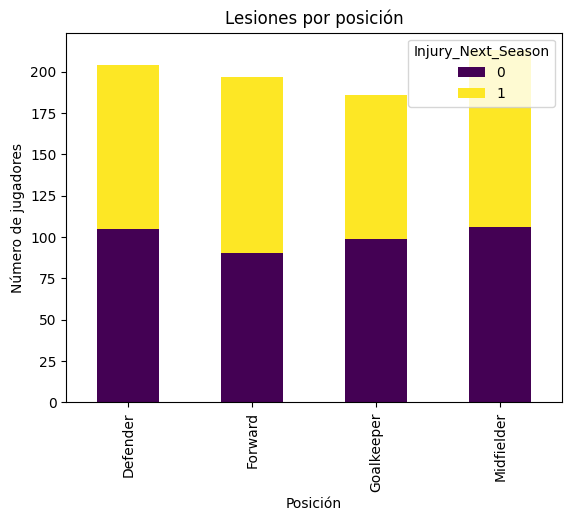

In [28]:
pd.crosstab(df['Position'], df['Injury_Next_Season']).plot(
    kind='bar',
    stacked=True,
    colormap='viridis'
)
plt.title("Lesiones por posición")
plt.xlabel("Posición")
plt.ylabel("Número de jugadores")
plt.show()

In [27]:
# Crear tabla de contingencia
tabla = pd.crosstab(df['Position'], df['Injury_Next_Season'])

# Mostrar tabla
print("Tabla de contingencia:")
print(tabla, "\n")

# Aplicar prueba Chi-cuadrado
chi2, p, dof, expected = chi2_contingency(tabla)

print(f"Chi-cuadrado: {chi2:.3f}")
print(f"Grados de libertad: {dof}")
print(f"p-valor: {p:.4f}\n")

# Interpretación automática
alpha = 0.05
if p < alpha:
    print("Existe una relación estadísticamente significativa entre la posición y la probabilidad de lesión.")
    print("Esto sugiere que la posición podría influir en el riesgo de lesión y debería considerarse en el análisis.")
else:
    print("No se encontró una relación significativa entre la posición y la probabilidad de lesión.")
    print("Las diferencias observadas entre posiciones podrían deberse al azar.")


Tabla de contingencia:
Injury_Next_Season    0    1
Position                    
Defender            105   99
Forward              90  107
Goalkeeper           99   87
Midfielder          106  107 

Chi-cuadrado: 2.422
Grados de libertad: 3
p-valor: 0.4895

No se encontró una relación significativa entre la posición y la probabilidad de lesión.
Las diferencias observadas entre posiciones podrían deberse al azar.


### Justificacion
#### En cuanto a la variable categorica Position, la grafica y la prueba chi-cuadrado nos indican que no influye significativamente en la variable objetivo, Injury_Next_Season

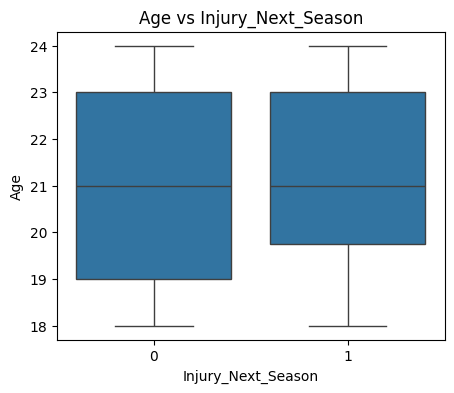

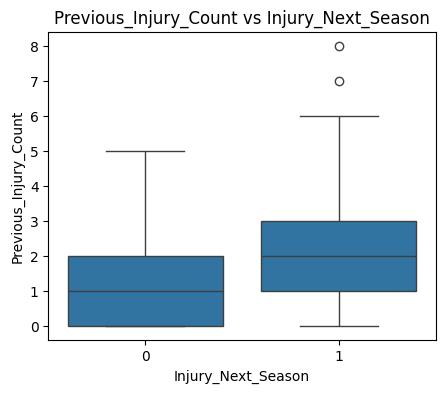

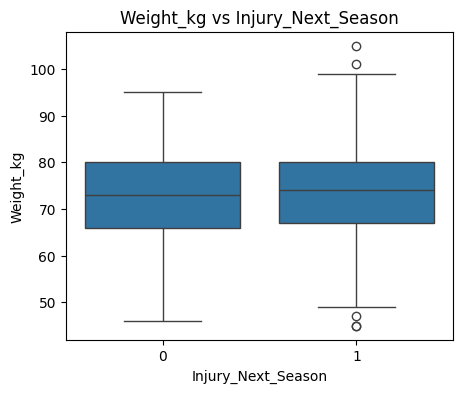

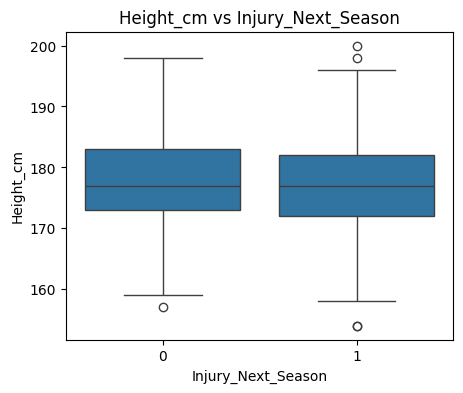

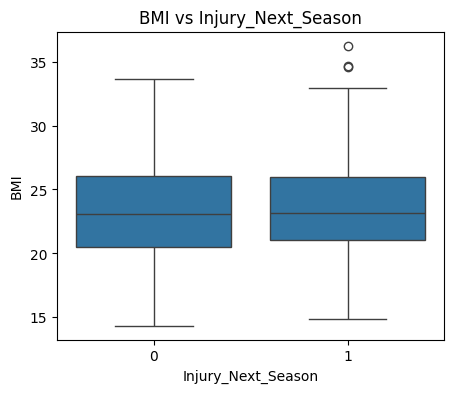

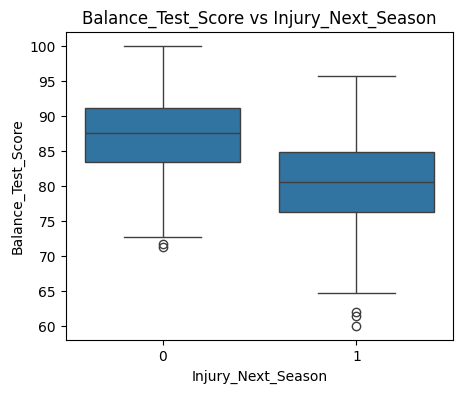

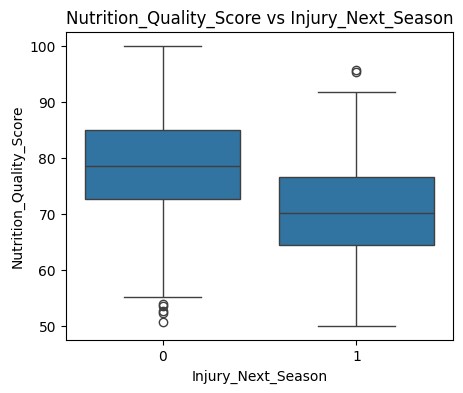

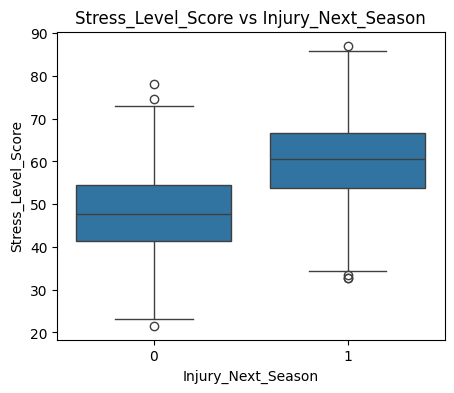

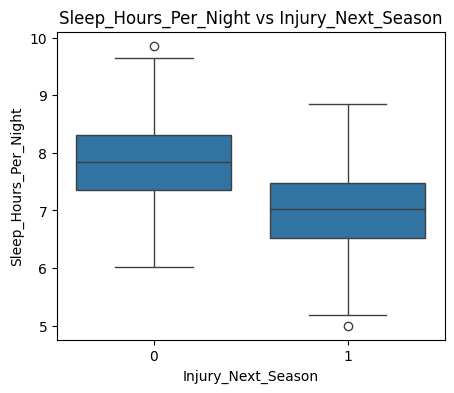

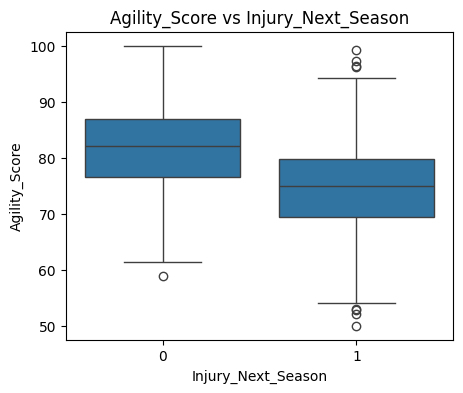

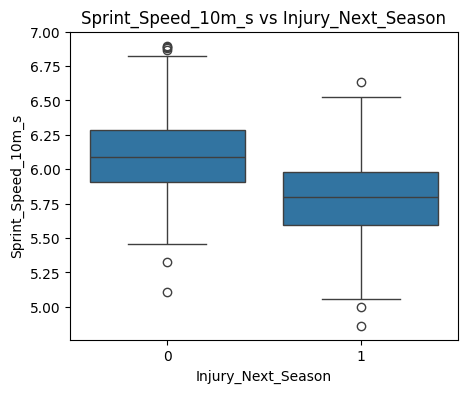

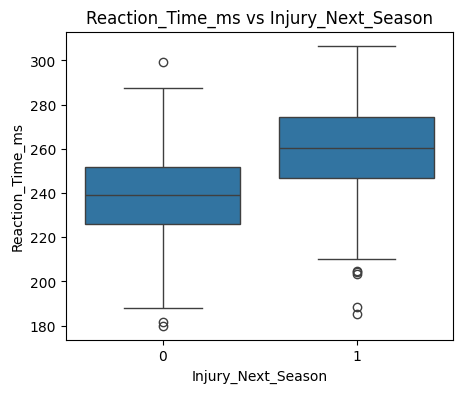

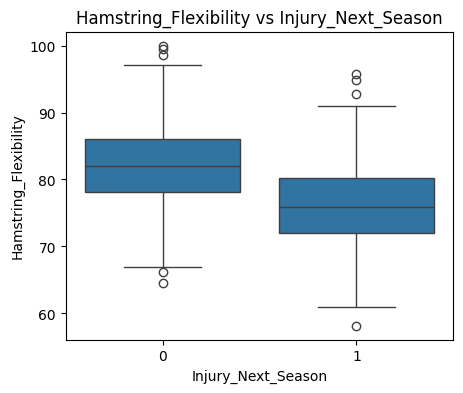

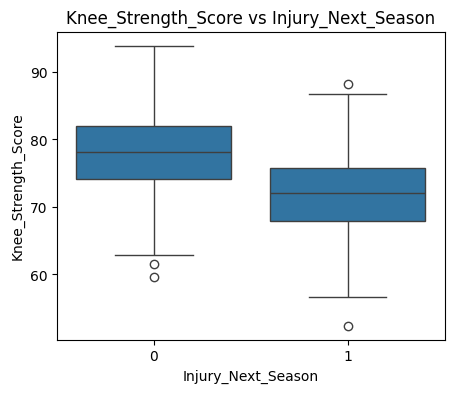

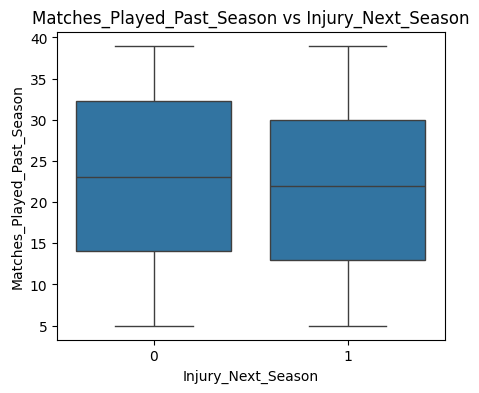

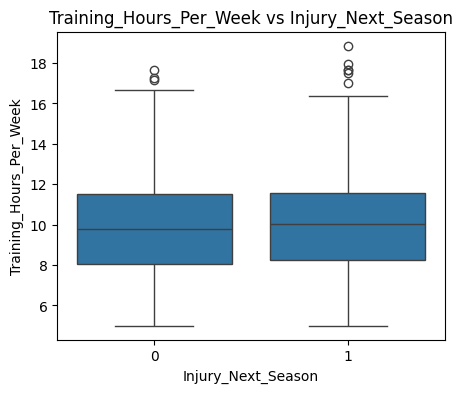

In [16]:
# --- Boxplots de variables numéricas vs variable objetivo ---
for col in numericas:
    plt.figure(figsize=(5,4))
    sns.boxplot(data=df, x='Injury_Next_Season', y=col)
    plt.title(f"{col} vs Injury_Next_Season")
    plt.show()

### Justificación
#### Se compara la media o distribución de cada variable númerica según lesión utilizando boxplots. Como resultado, tenemos indicios de que variables podrian influir en que un jugador se lesione la siguiente temporada. No obstante, para confirmar estas suposiciones se hace un test de correlacion, donde las variables con correlación alta (positiva o negativa) y p-valor bajo (<0.05) son las más relacionadas con el riesgo de lesión.

In [17]:
for col in numericas:
    corr, p = pointbiserialr(df['Injury_Next_Season'], df[col])
    print(f"{col}: correlación = {corr:.3f}, p-valor = {p:.3f}")

Age: correlación = 0.021, p-valor = 0.546
Previous_Injury_Count: correlación = 0.382, p-valor = 0.000
Weight_kg: correlación = 0.021, p-valor = 0.550
Height_cm: correlación = -0.055, p-valor = 0.121
BMI: correlación = 0.047, p-valor = 0.181
Balance_Test_Score: correlación = -0.495, p-valor = 0.000
Nutrition_Quality_Score: correlación = -0.412, p-valor = 0.000
Stress_Level_Score: correlación = 0.530, p-valor = 0.000
Sleep_Hours_Per_Night: correlación = -0.511, p-valor = 0.000
Agility_Score: correlación = -0.394, p-valor = 0.000
Sprint_Speed_10m_s: correlación = -0.471, p-valor = 0.000
Reaction_Time_ms: correlación = 0.471, p-valor = 0.000
Hamstring_Flexibility: correlación = -0.450, p-valor = 0.000
Knee_Strength_Score: correlación = -0.455, p-valor = 0.000
Matches_Played_Past_Season: correlación = -0.044, p-valor = 0.215
Training_Hours_Per_Week: correlación = 0.034, p-valor = 0.340


## Variables seleccionadas para el Objetivo 1.
### Warmup_Routine_Adherence, Previous_Injury_Count, Balance_Test_Score, Nutrition_Quality_Score, Stress_Level_Score, Sleep_Hours_Per_Night, Agility_Score, Sprint_Speed_10m_s, Reaction_Time_ms, Hamstring_Flexibility, Knee_Strength_Score

## Seleccion variables Objetivo 2.

#### Para este objetivo no se van a analizar todas las variables, ya que, en este se especifica que se tomaran en cuenta las caracteristicas fisicas. Por ende, se descartan las variables: Previous_Injury_Count, Nutrition_Quality_Score, Stress_Level_Score, Sleep_Hours_Per_Night, Matches_Played_Past_Season, Training_Hours_Per_Week, Warmup_Routine_Adherence, Injury_Next_Season.

In [44]:
variables_fisicas = [
    'Age',
    'Height_cm',
    'Weight_kg',
    'BMI',
    'Balance_Test_Score',
    'Agility_Score',
    'Sprint_Speed_10m_s',
    'Reaction_Time_ms',
    'Hamstring_Flexibility',
    'Knee_Strength_Score'
]


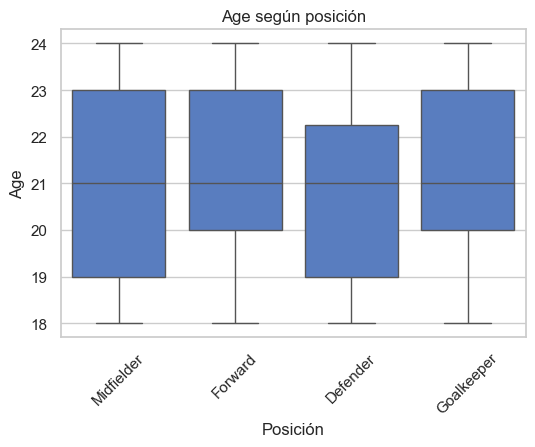

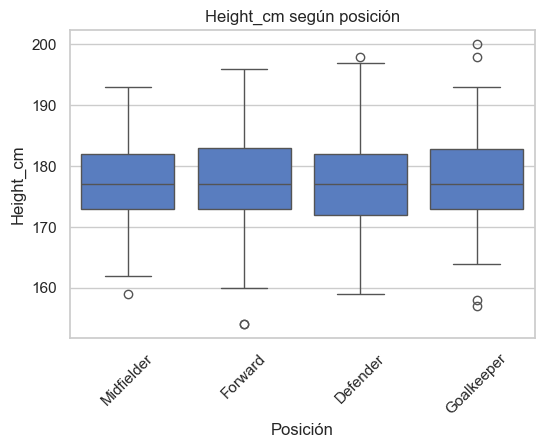

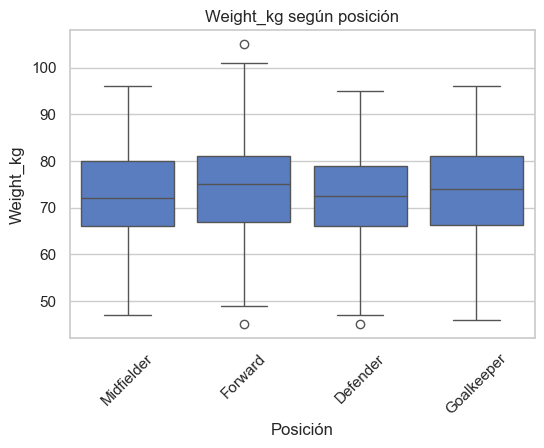

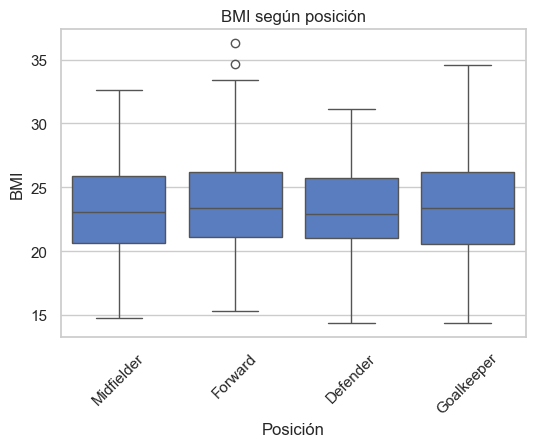

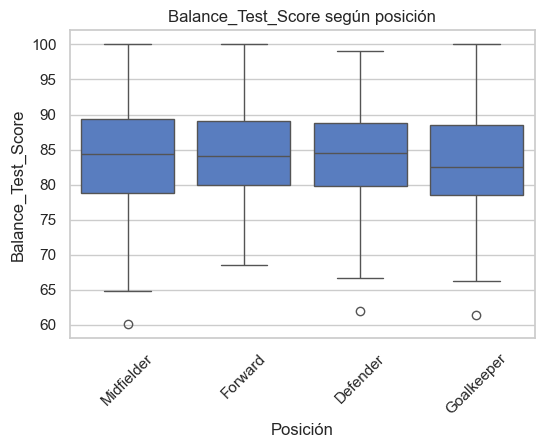

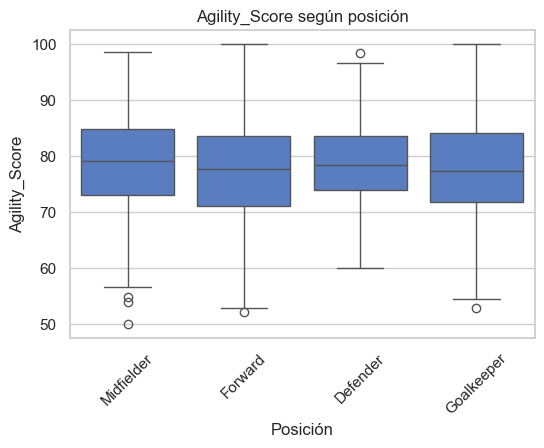

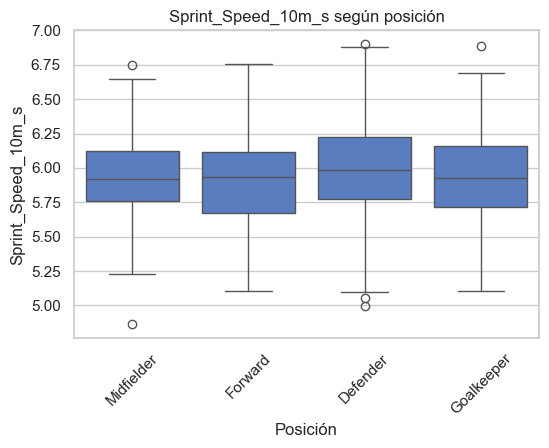

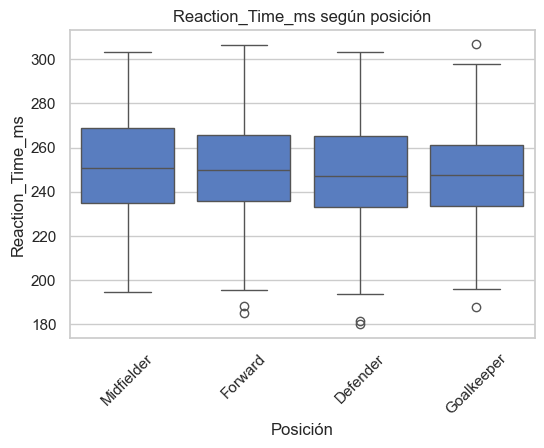

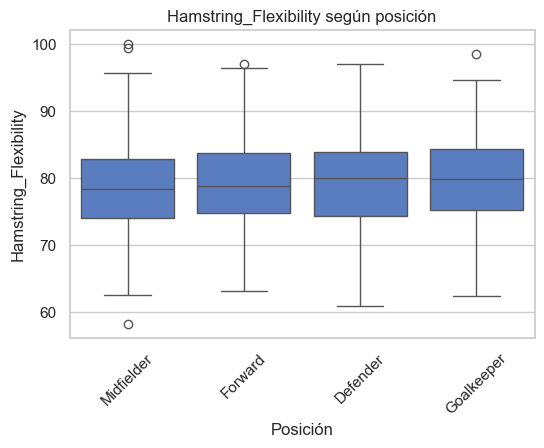

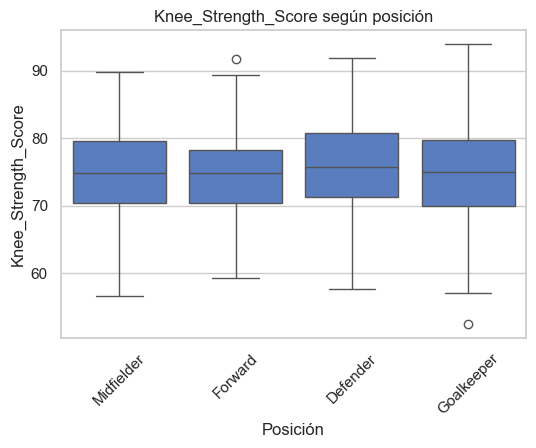

In [45]:
sns.set(style="whitegrid", palette="muted")

for col in variables_fisicas:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x='Position', y=col)
    plt.title(f"{col} según posición")
    plt.xlabel("Posición")
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.show()



### Justificacion
#### A simple vista no hay diferencias claras entre posiciones, ya que los boxplots muestran distribuciones similares. Asi que se decide aplicar un test estadistico: ANOVA.

#### ANOVA. Es el equivalente a una correlación entre una variable numérica y una categórica multiclase.

In [46]:
significativas = []
no_significativas = []

for col in variables_fisicas:
    grupos = [df[df['Position']==p][col] for p in df['Position'].unique()]
    f, p = f_oneway(*grupos)
    print(f"{col}: p-valor = {p:.4f}")
    if p < 0.05:
        significativas.append(col)
    else:
        no_significativas.append(col)

print("\nVariables con diferencia significativa entre posiciones:")
print(significativas)

print("\nVariables sin diferencia significativa:")
print(no_significativas)

Age: p-valor = 0.0569
Height_cm: p-valor = 0.9623
Weight_kg: p-valor = 0.4209
BMI: p-valor = 0.6166
Balance_Test_Score: p-valor = 0.8719
Agility_Score: p-valor = 0.3171
Sprint_Speed_10m_s: p-valor = 0.0649
Reaction_Time_ms: p-valor = 0.1833
Hamstring_Flexibility: p-valor = 0.2707
Knee_Strength_Score: p-valor = 0.1927

Variables con diferencia significativa entre posiciones:
[]

Variables sin diferencia significativa:
['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Balance_Test_Score', 'Agility_Score', 'Sprint_Speed_10m_s', 'Reaction_Time_ms', 'Hamstring_Flexibility', 'Knee_Strength_Score']


#### Cuando p < 0.05, la variable sí influye en la posición, ya que sus medias varían entre clases. En este caso, ninguna variable ni fisica ni de rendimiento tiene una diferencia significativa. Como consecuencia se decide cambiar el objetivo 2.

## Nuevo objetivo 2: Clasificar a los jugadores según su desempeño físico y sus niveles de agilidad, velocidad y fuerza, con el propósito de analizar patrones de rendimiento dentro del equipo.

### Con este nuevo objetivo en mente, solamente se seleccionan variables relacionadas al rendimiento fisico.
## Variables Objetivo 2: 
### 'Agility_Score', 'Sprint_Speed_10m_s', 'Reaction_Time_ms', 'Balance_Test_Score', 'Hamstring_Flexibility', 'Knee_Strength_Score'.

In [47]:
# Dataset Objetivo 1: Riesgo de lesión
df_obj1 = df[['Warmup_Routine_Adherence', 'Previous_Injury_Count', 'Balance_Test_Score',
              'Nutrition_Quality_Score', 'Stress_Level_Score', 'Sleep_Hours_Per_Night',
              'Agility_Score', 'Sprint_Speed_10m_s', 'Reaction_Time_ms',
              'Hamstring_Flexibility', 'Knee_Strength_Score']]

# Dataset Objetivo 2: Desempeño físico
df_obj2 = df[['Agility_Score', 'Sprint_Speed_10m_s', 'Reaction_Time_ms',
              'Balance_Test_Score', 'Hamstring_Flexibility', 'Knee_Strength_Score']]


## 7. Indicar que hacer con los outliers, valores de alta y baja varianza y justificar.

In [48]:
def detectar_outliers(df):
    outliers = {}
    for col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers_count = ((df[col] < lower) | (df[col] > upper)).sum()
        outliers[col] = outliers_count
    return pd.DataFrame.from_dict(outliers, orient='index', columns=['Cantidad de outliers'])

print("---- OUTLIERS Objetivo 1 ----")
print(detectar_outliers(df_obj1), "\n")

print("---- OUTLIERS Objetivo 2 ----")
print(detectar_outliers(df_obj2))


---- OUTLIERS Objetivo 1 ----
                          Cantidad de outliers
Warmup_Routine_Adherence                     0
Previous_Injury_Count                       63
Balance_Test_Score                           3
Nutrition_Quality_Score                      1
Stress_Level_Score                           2
Sleep_Hours_Per_Night                        2
Agility_Score                                7
Sprint_Speed_10m_s                           9
Reaction_Time_ms                             3
Hamstring_Flexibility                        4
Knee_Strength_Score                          2 

---- OUTLIERS Objetivo 2 ----
                       Cantidad de outliers
Agility_Score                             7
Sprint_Speed_10m_s                        9
Reaction_Time_ms                          3
Balance_Test_Score                        3
Hamstring_Flexibility                     4
Knee_Strength_Score                       2


#### En el conjunto de datos del Objetivo 1, se identificaron algunos valores atípicos en variables como Previous_Injury_Count (63 casos), Sprint_Speed_10m_s, Agility_Score y Hamstring_Flexibility. En cambio, el dataset del Objetivo 2 presentó una menor cantidad de outliers, concentrados principalmente en las mismas variables de desempeño físico.

In [49]:
def analizar_varianza(df):
    varianzas = df.var().sort_values(ascending=False)
    print("Varianza por variable:\n")
    print(varianzas)
    baja_varianza = varianzas[varianzas < 0.01]
    alta_varianza = varianzas[varianzas > varianzas.mean() + 2*varianzas.std()]
    return baja_varianza, alta_varianza

print("\n---- VARIANZA Objetivo 1 ----")
baja1, alta1 = analizar_varianza(df_obj1)

print("\nVariables con baja varianza (Objetivo 1):")
print(baja1)
print("\nVariables con alta varianza (Objetivo 1):")
print(alta1)

print("\n---- VARIANZA Objetivo 2 ----")
baja2, alta2 = analizar_varianza(df_obj2)

print("\nVariables con baja varianza (Objetivo 2):")
print(baja2)
print("\nVariables con alta varianza (Objetivo 2):")
print(alta2)



---- VARIANZA Objetivo 1 ----
Varianza por variable:

Reaction_Time_ms            507.708472
Stress_Level_Score          130.442504
Nutrition_Quality_Score      86.953744
Agility_Score                77.007964
Balance_Test_Score           48.047871
Hamstring_Flexibility        46.000030
Knee_Strength_Score          44.524982
Previous_Injury_Count         1.670774
Sleep_Hours_Per_Night         0.629139
Warmup_Routine_Adherence      0.240795
Sprint_Speed_10m_s            0.108329
dtype: float64

Variables con baja varianza (Objetivo 1):
Series([], dtype: float64)

Variables con alta varianza (Objetivo 1):
Reaction_Time_ms    507.708472
dtype: float64

---- VARIANZA Objetivo 2 ----
Varianza por variable:

Reaction_Time_ms         507.708472
Agility_Score             77.007964
Balance_Test_Score        48.047871
Hamstring_Flexibility     46.000030
Knee_Strength_Score       44.524982
Sprint_Speed_10m_s         0.108329
dtype: float64

Variables con baja varianza (Objetivo 2):
Series([], dt

#### El análisis de varianza mostró que ninguna variable presenta una varianza extremadamente baja, lo que indica que todas aportan información útil al modelo. Sin embargo, la variable Reaction_Time_ms evidenció una varianza considerablemente alta en ambos objetivos, reflejando una gran dispersión de los tiempos de reacción entre jugadores.

In [ ]:
# Crear el escalador
scaler = StandardScaler()

# Aplicar a cada dataset
X_obj1_scaled = scaler.fit_transform(df_obj1)
X_obj2_scaled = scaler.fit_transform(df_obj2)

# Convertir nuevamente a DataFrame
X_obj1_scaled = pd.DataFrame(X_obj1_scaled, columns=df_obj1.columns)
X_obj2_scaled = pd.DataFrame(X_obj2_scaled, columns=df_obj2.columns)

# Verificar resultados
X_obj2_scaled.describe()


,Agility_Score,Sprint_Speed_10m_s,Reaction_Time_ms,Balance_Test_Score,Hamstring_Flexibility,Knee_Strength_Score
count,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02
mean,-1.062483e-15,-2.686740e-15,-8.437695e-17,-3.819167e-16,1.136868e-15,9.614531e-16
std,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00
min,-3.231646e+00,-3.303432e+00,-3.082970e+00,-3.431752e+00,-3.094343e+00,-3.380339e+00
25%,-6.460620e-01,-6.581184e-01,-6.809421e-01,-6.910934e-01,-6.872383e-01,-6.749001e-01
50%,-3.856010e-05,-3.445484e-02,-1.314116e-02,4.675673e-02,4.984471e-03,9.699807e-03
75%,6.558977e-01,6.389859e-01,6.964042e-01,7.283570e-01,6.873698e-01,7.046740e-01
max,2.469653e+00,2.885750e+00,2.544935e+00,2.333897e+00,3.075479e+00,2.844224e+00


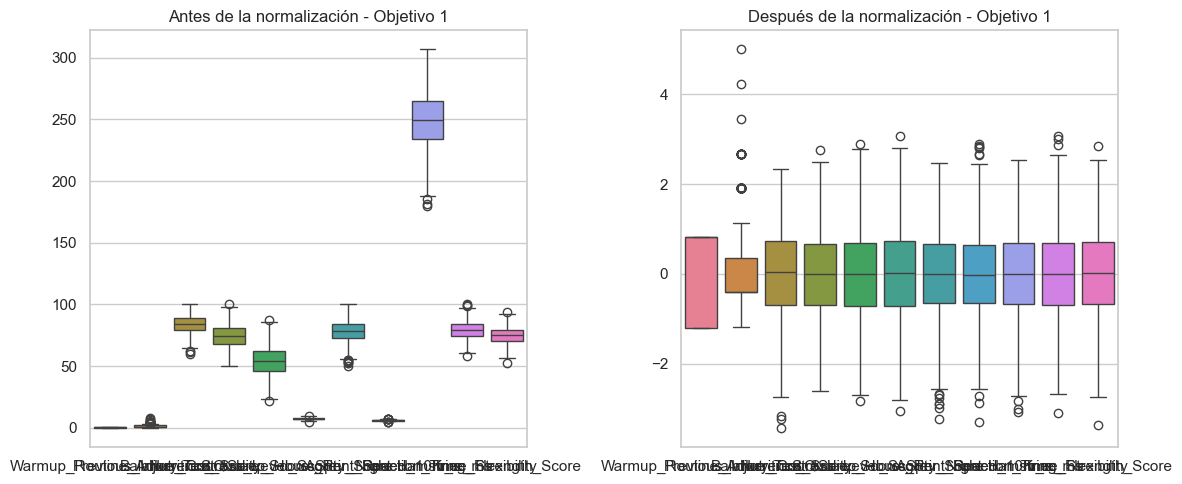

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df_obj1, ax=axes[0])
axes[0].set_title("Antes de la normalización - Objetivo 1")

sns.boxplot(data=X_obj1_scaled, ax=axes[1])
axes[1].set_title("Después de la normalización - Objetivo 1")

plt.tight_layout()
plt.show()


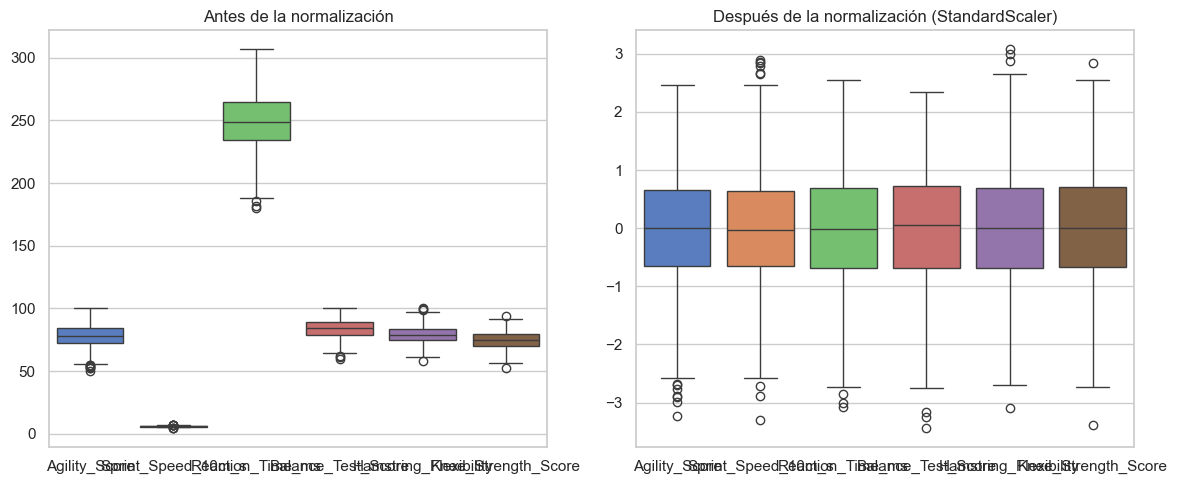

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.boxplot(data=df_obj2, ax=axes[0])
axes[0].set_title("Antes de la normalización")

sns.boxplot(data=X_obj2_scaled, ax=axes[1])
axes[1].set_title("Después de la normalización (StandardScaler)")

plt.tight_layout()
plt.show()


### Justificacion
#### A partir de los resultados obtenidos se identificó la presencia de valores atípicos que, más que errores, representan jugadores con características físicas extremas. Asimismo, se observó una alta variabilidad en la variable Reaction_Time_ms, la cual podría influir en el modelado. Por ello, se aplicó el método de normalización estándar (StandardScaler), que centra las variables en una media de cero y una desviación estándar de uno. Esta técnica garantiza que todas las variables contribuyan equitativamente al análisis de clustering, evitando que aquellas con mayores magnitudes o dispersión dominen el proceso de agrupamiento.

## 8. Realizar un mapa de calor o de correlación y eliminar aquellas variables muy correlacionadas (indicar por qué se pueden eliminar).

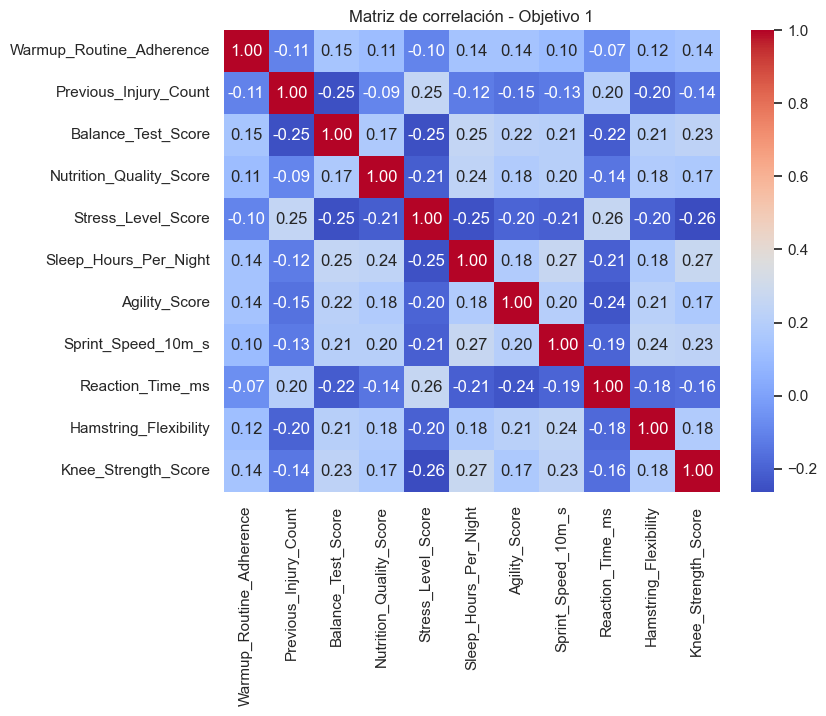

In [64]:
corr = X_obj1_scaled.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de correlación - Objetivo 1")
plt.show()

In [73]:
# Umbral de correlación (ajustable)
threshold = 0.85

# Variables con alta correlación
correladas = set()
for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > threshold:
            colname = corr.columns[i]
            correladas.add(colname)

print("Variables con alta correlación (>|0.85|):")
print(correladas)

X_obj1_final = X_obj1_scaled.drop(columns=list(correladas))

Variables con alta correlación (>|0.85|):
set()


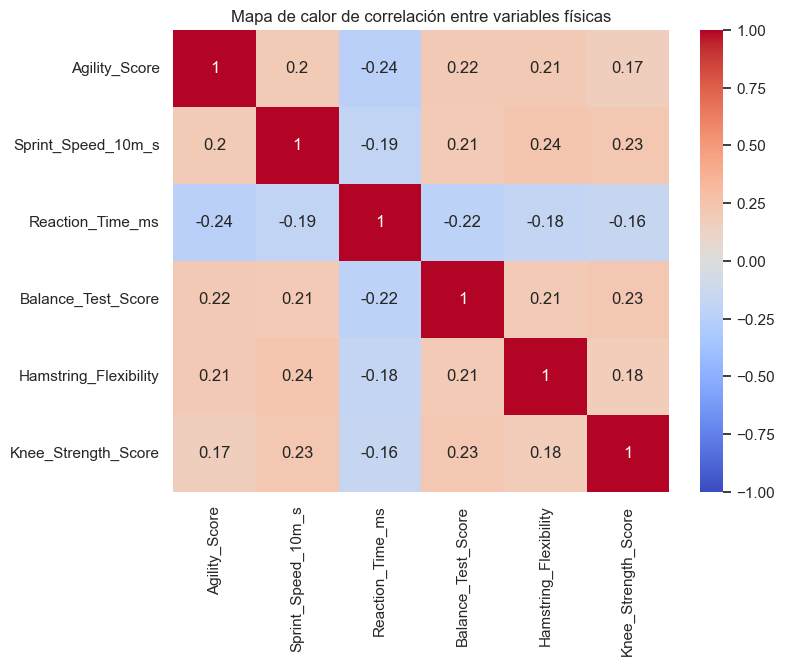

In [74]:
# Calcular matriz de correlación
corr = X_obj2_scaled.corr()

# Visualizar mapa de calor
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title("Mapa de calor de correlación entre variables físicas")
plt.show()

In [76]:
# Umbral de correlación (ajustable)
threshold = 0.85

# Variables con alta correlación
correladas = set()
for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > threshold:
            colname = corr.columns[i]
            correladas.add(colname)

print("Variables con alta correlación (>|0.85|):")
print(correladas)

X_obj2_final = X_obj2_scaled.drop(columns=list(correladas))


Variables con alta correlación (>|0.85|):
set()


### Justificacion
#### Las variables muy correlacionadas pueden aportar información redundante y distorsionar la formación de grupos. No obstante, no se hallaron variables que cumplieran con esta condicion, por ende, no se eliminaron variables adicionales.

## 9. Realizar un algoritmo de KMeans, Kmedoids, o SOM. Genere la cantidad de clusters necesarios (use coeficiente de silueta, o de método del codo), y por cada cluster descríbalo e indique que lo hace diferente a los otros cluster.

## Objetivo 1.

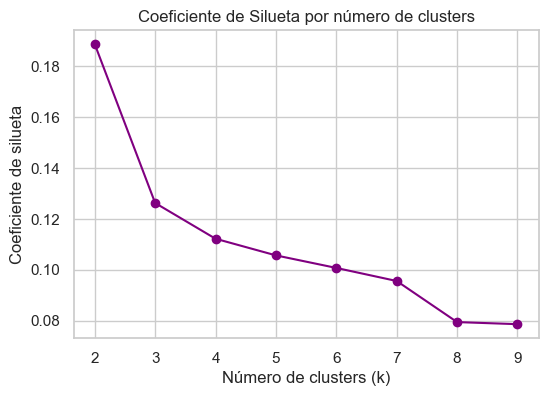

In [77]:
X = X_obj1_final  # dataset final del Objetivo 2

silhouette_scores = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(6,4))
plt.plot(range(2,10), silhouette_scores, marker='o', color='purple')
plt.title("Coeficiente de Silueta por número de clusters")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Coeficiente de silueta")
plt.show()

#### El análisis mediante el coeficiente de silueta indicó que el número óptimo de agrupaciones es k = 2, con un valor de silueta aproximado de 0.18, lo que refleja una separación moderada entre los grupos.

In [80]:
kmeans = KMeans(n_clusters=2, random_state=42)
df_clusters = X.copy()
df_clusters['Cluster'] = kmeans.fit_predict(X)

# Ver distribución
df_clusters['Cluster'].value_counts()

Cluster
0    404
1    396
Name: count, dtype: int64

#### El modelo K-Means formó dos clusters con una distribución equilibrada

In [79]:
cluster_summary = df_clusters.groupby('Cluster').mean()
print(cluster_summary)


         Warmup_Routine_Adherence  Previous_Injury_Count  Balance_Test_Score  \
Cluster                                                                        
0                        0.285733              -0.384468            0.497941   
1                       -0.291505               0.392235           -0.508001   

         Nutrition_Quality_Score  Stress_Level_Score  Sleep_Hours_Per_Night  \
Cluster                                                                       
0                       0.403010           -0.522457               0.527172   
1                      -0.411151            0.533011              -0.537822   

         Agility_Score  Sprint_Speed_10m_s  Reaction_Time_ms  \
Cluster                                                        
0             0.412571            0.459512         -0.481906   
1            -0.420905           -0.468795          0.491642   

         Hamstring_Flexibility  Knee_Strength_Score  
Cluster                                            

#### Cluster 0: Se caracteriza por jugadores con mejores hábitos y condiciones físicas. Presentan mayores valores en Warmup_Routine_Adherence, Balance_Test_Score, Nutrition_Quality_Score, Sleep_Hours_Per_Night, Agility_Score, Sprint_Speed_10m_s, Hamstring_Flexibility y Knee_Strength_Score. Además, muestran menor estrés (Stress_Level_Score) y menos lesiones previa (Previous_Injury_Count), lo cual sugiere una menor propensión a lesiones futuras.
#### Cluster 1: Agrupa jugadores con peores indicadores de recuperación y rendimiento físico, evidenciando menores niveles de balance, agilidad, fuerza y flexibilidad. A su vez, presentan mayor cantidad de lesiones previas, mayor estrés y menor calidad de sueño y nutrición, factores que pueden incrementar el riesgo de lesión.

## Objetivo 2.

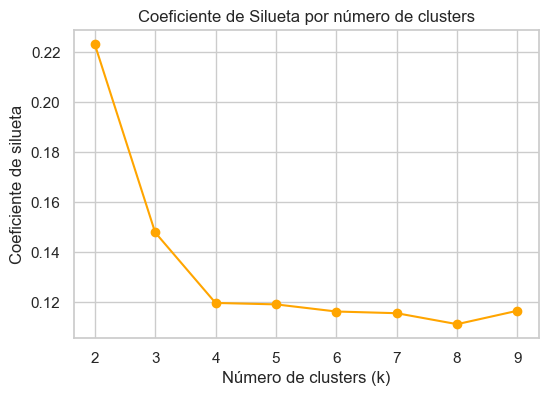

In [ ]:
X = X_obj2_final  # dataset final del Objetivo 2

silhouette_scores = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(6,4))
plt.plot(range(2,10), silhouette_scores, marker='o', color='orange')
plt.title("Coeficiente de Silueta por número de clusters")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Coeficiente de silueta")
plt.show()

#### El análisis mediante el coeficiente de silueta indicó que el número óptimo de agrupaciones es k = 2, con un valor de silueta aproximado de 0.22, lo que refleja una separación moderada entre los grupos.

In [81]:
kmeans = KMeans(n_clusters=2, random_state=42)
df_clusters = X.copy()
df_clusters['Cluster'] = kmeans.fit_predict(X)

# Ver distribución
df_clusters['Cluster'].value_counts()


Cluster
0    404
1    396
Name: count, dtype: int64

#### El modelo K-Means formó dos clusters con una distribución equilibrada

In [ ]:
cluster_summary = df_clusters.groupby('Cluster').mean()
print(cluster_summary)


         Agility_Score  Sprint_Speed_10m_s  Reaction_Time_ms  \
Cluster                                                        
0             0.484983            0.459928         -0.480307   
1            -0.517566           -0.490827          0.512576   

         Balance_Test_Score  Hamstring_Flexibility  Knee_Strength_Score  
Cluster                                                                  
0                  0.520709               0.488734             0.447827  
1                 -0.555692              -0.521569            -0.477914  


#### Cluster 0: Representa a los jugadores con mayor desempeño físico general. Presentan valores superiores en agilidad (Agility_Score), velocidad (Sprint_Speed_10m_s), balance (Balance_Test_Score), flexibilidad (Hamstring_Flexibility) y fuerza (Knee_Strength_Score).Además, registran menores tiempos de reacción (Reaction_Time_ms), lo que indica una mejor capacidad de respuesta y coordinación motora. En conjunto, este grupo se asocia con jugadores físicamente más preparados y eficientes en términos de rendimiento.
#### Cluster 1: Agrupa a jugadores con rendimiento físico inferior. Presentan menores puntajes en agilidad, velocidad, fuerza, flexibilidad y balance, junto con mayores tiempos de reacción, lo que refleja menor explosividad y respuesta motora. Este perfil puede asociarse con jugadores en desarrollo o con menor preparación física.